In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.float_format', '{:,.0f}'.format)
%matplotlib inline

In [47]:
df = pd.read_csv('data/Microsoft_Stock.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,41,41,40,41,36865322
1,4/2/2015 16:00:00,41,41,40,40,37487476
2,4/6/2015 16:00:00,40,42,40,42,39223692
3,4/7/2015 16:00:00,42,42,41,42,28809375
4,4/8/2015 16:00:00,41,42,41,41,24753438


# **Data Description**

This dataset contains the stock information of Microsoft from 01.04.2015 to 01.04.2021.

- **Date**: Date,
- **Open**: Opening price,
- **High**: Highest value of the day,
- **Low**: Lowest value of the day,
- **Close**: Closing price,
- **Volume**: Number of shares traded on that day.

In [6]:
df.shape

(1511, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1511 non-null   object 
 1   Open    1511 non-null   float64
 2   High    1511 non-null   float64
 3   Low     1511 non-null   float64
 4   Close   1511 non-null   float64
 5   Volume  1511 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 71.0+ KB


In [10]:
df.describe()

,Open,High,Low,Close,Volume
count,"1,511","1,511","1,511","1,511","1,511"
mean,107,108,106,107,"30,198,625"
std,57,57,56,57,"14,252,659"
min,40,41,40,40,"101,612"
25%,58,58,57,58,"21,362,129"
50%,94,95,93,94,"26,629,615"
75%,139,140,138,139,"34,319,616"
max,245,246,243,245,"135,227,059"


In [14]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [48]:
df['ds'] = pd.to_datetime(df['Date']).dt.date
df['y'] = df['Close']

# **Data Visualisation**

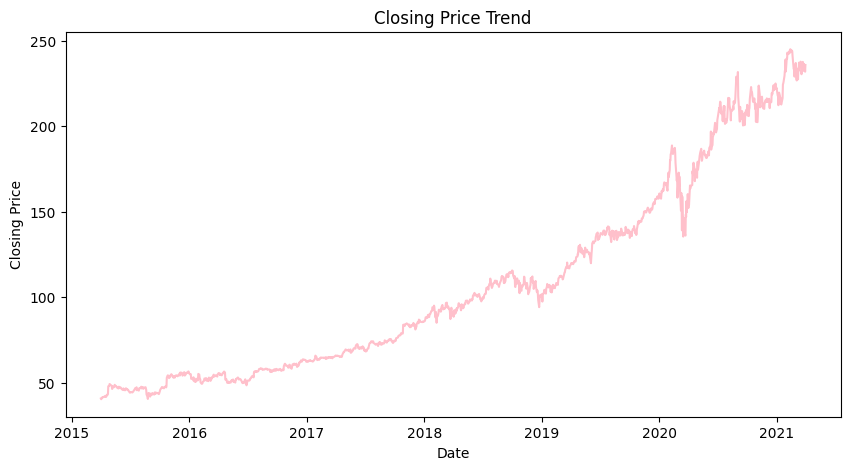

In [57]:
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'], label='Closing price', color='pink')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Closing Price Trend')
plt.show()

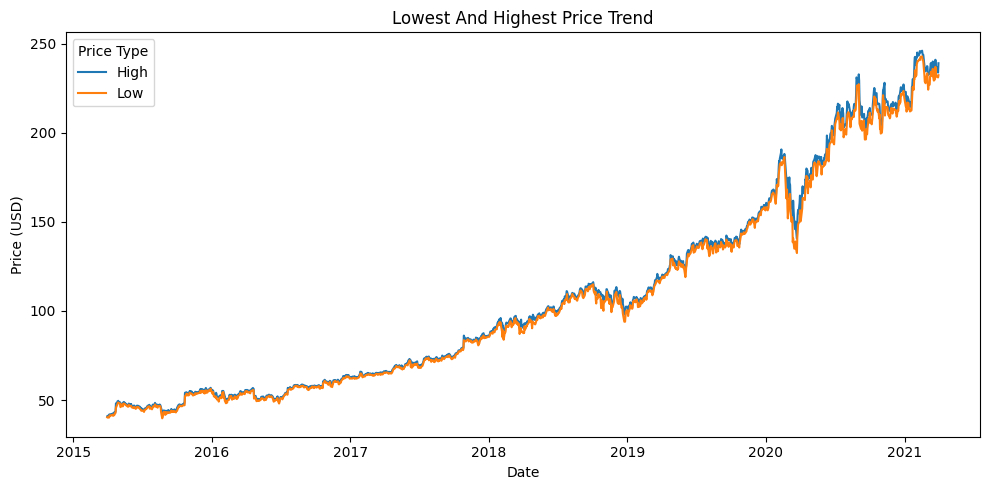

In [58]:
df_long = pd.melt(df, id_vars=['ds'], value_vars=['High', 'Low'], 
                  var_name='Price_Type', value_name='Price')

plt.figure(figsize=(10,5))
sns.lineplot(data=df_long, x='ds', y='Price', hue='Price_Type')

plt.title('Lowest And Highest Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(title='Price Type')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Trading Volume Over Time')

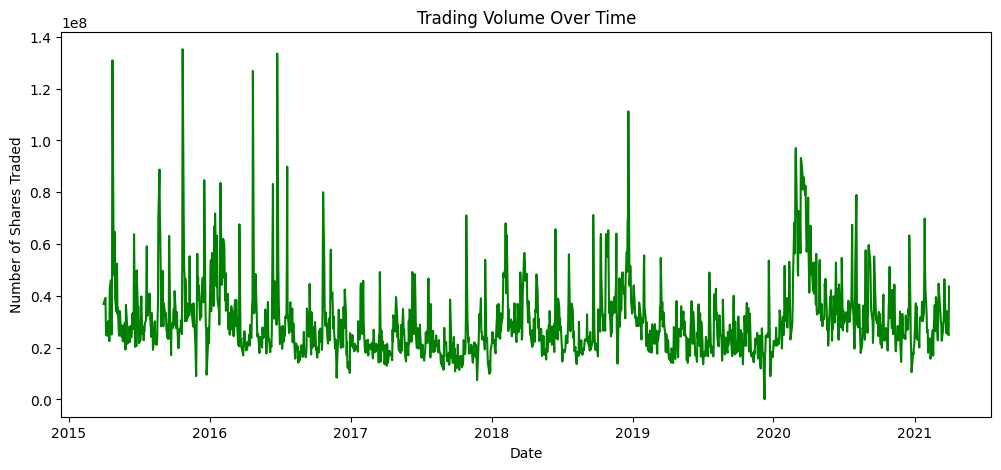

In [61]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='ds', y='Volume', color='green')
plt.xlabel('Date')
plt.ylabel('Number of Shares Traded')
plt.title('Trading Volume Over Time')

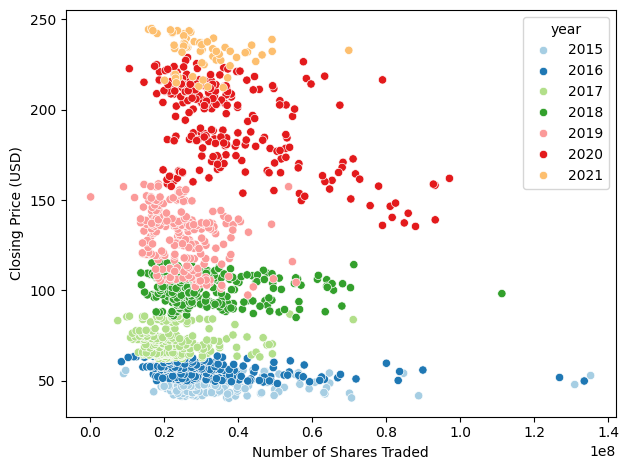

In [49]:
df['year'] = pd.to_datetime(df['ds'], errors='coerce').dt.year

sns.scatterplot(data=df, x='Volume', y='Close', hue='year', palette='Paired')
plt.xlabel("Number of Shares Traded")
plt.ylabel("Closing Price (USD)")
plt.tight_layout()
plt.show()

# **Predictive Modelling (Time Series)**

### 1. Prophet

In [88]:
from prophet import Prophet

df = df[['ds', 'y']]
train = df[:-365]
test = df[-365:]

model = Prophet(daily_seasonality=True)
model.fit(train)

14:32:16 - cmdstanpy - INFO - Chain [1] start processing
14:32:17 - cmdstanpy - INFO - Chain [1] done processing


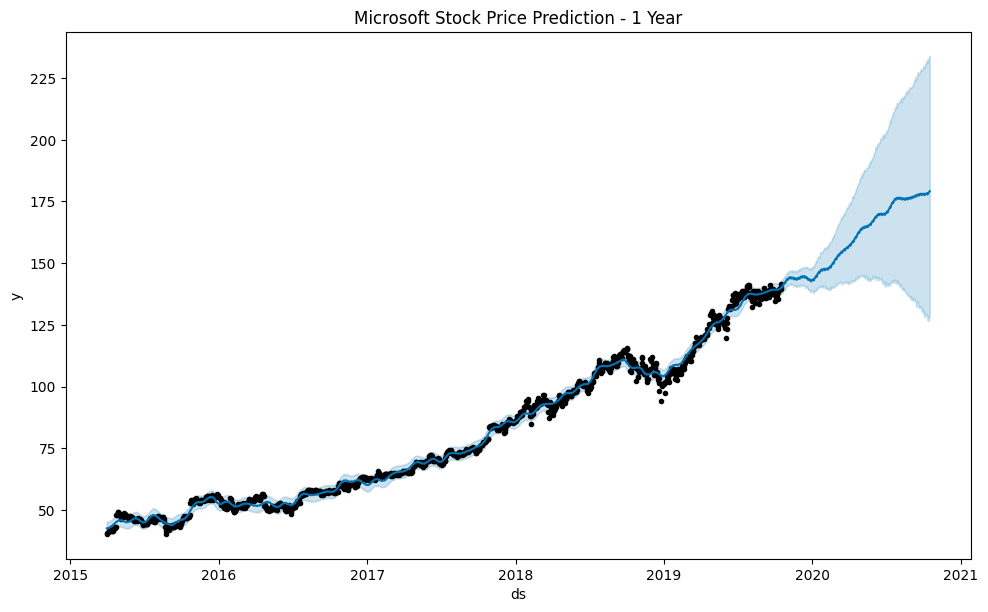

In [89]:
future = model.make_future_dataframe(periods=365)    # forecast for the next 365 days
forecast = model.predict(future)

model.plot(forecast)
plt.grid(False)
plt.title('Microsoft Stock Price Prediction - 1 Year')
plt.show()

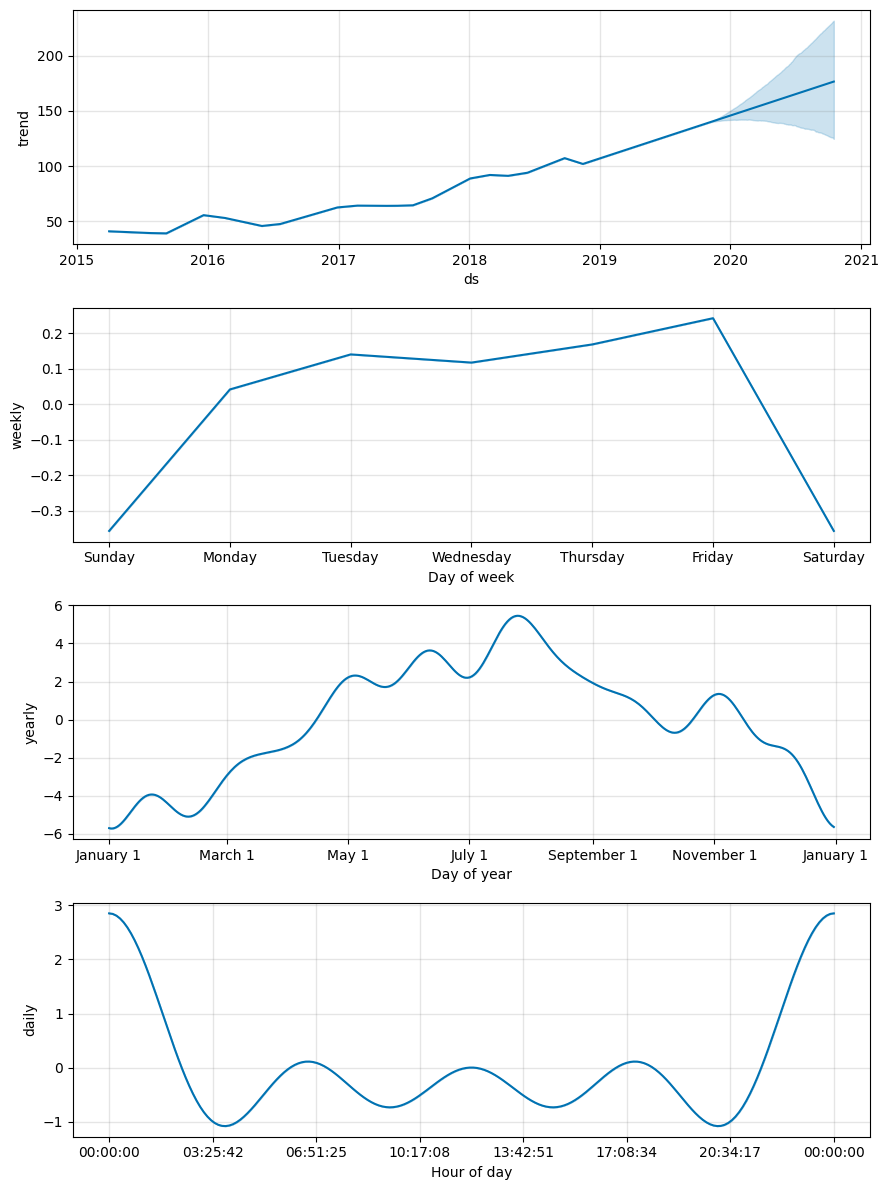

In [90]:
model.plot_components(forecast)
plt.show()

In [94]:
from sklearn.metrics import mean_squared_error

df['ds'] = pd.to_datetime(df['ds'])
test.loc[:, 'ds'] = pd.to_datetime(test['ds'])
forecast['ds'] = pd.to_datetime(forecast['ds'])
test_filtered = test[test['ds'].isin(forecast['ds'])]
forecast_test = forecast[forecast['ds'].isin(test_filtered['ds'])]
test_filtered = test_filtered.reset_index(drop=True)
forecast_test = forecast_test.reset_index(drop=True)

rmse = mean_squared_error(test_filtered['y'], forecast_test['yhat'], squared=False)
mape = np.mean(np.abs((test_filtered['y'] - forecast_test['yhat']) / test_filtered['y'])) * 100

print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}')

Root Mean Squared Error: 24.08
Mean Absolute Percentage Error: 10.70


**To be continued.**